# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook provides a hands-on introduction to **Extreme Value Theory (EVT)** for portfolio risk management. We explore EVT in two key applications:

1. A **basic univariate setting**, using a single ETF position to illustrate tail modeling and threshold selection.
2. An **advanced simulation-based application**, where EVT is combined with Monte Carlo methods to estimate **VaR at extremely high confidence levels** (e.g., 99.97%).

For each case, we review the main concepts, such as the Generalized Pareto Distribution (GPD), then show how to implement EVT using our Python package and example data.


### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

---

## Part I: Univariate EVT with a Single Asset

We start with a simple, transparent setting to introduce Extreme Value Theory: modeling tail risk for a **single asset** — the S&P 500 index (^GSPC). The S&P 500 is the most widely followed benchmark of U.S. equities and is often used as a representative proxy for the overall stock market.

Note: All models in this section are based on **daily return data**.

Feel free to replace the ticker with another asset of interest. Popular choices include:
- Vanguard Total World Stock ETF (`VT`)
- Apple (`AAPL`)
- Nvidia (`NVDA`)
- Microsoft (`MSFT`)
- Tesla (`TSLA`)

In [4]:
# Download the SP500 data from YF
sp_data = yf.download("^GSPC", start="2000-01-01", end="2025-01-01")

# Check for missing values in the entire DataFrame (including the new column)
print(sp_data.isnull().sum())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64


In [5]:
# Compute percentage returns and remove the first NaN
sp_data["Percent Returns"] = sp_data["Close"].pct_change()
sp_returns = sp_data["Percent Returns"].dropna()

In [6]:
sp_returns.head()

Date
2000-01-04   -0.038345
2000-01-05    0.001922
2000-01-06    0.000956
2000-01-07    0.027090
2000-01-10    0.011190
Name: Percent Returns, dtype: float64

If you want to **download and save the return series as a CSV**, you can do:

```python
sp_returns.to_csv("sp_returns.csv")
```

If you want to **load your own return series from a CSV**, use:

```python
sp_returns = pd.read_csv("your_file.csv", index_col=0, parse_dates=True).squeeze()
```

Make sure:
- The CSV contains one column of daily return values
- The first column becomes the date index
- Dates are properly parsed for the analysis
- Returns are already computed (not prices)

Note: You are responsible for return calculation and data cleaning.  

---


### EVT Introduction

Extreme Value Theory provides a parametric framework to estimate tail risk by modeling the extreme values beyond a high threshold. It is especially useful when data is scarce or when high-confidence VaRs are needed.

The fitted distribution in the tail is controlled by two parameters:  
- ξ (shape): tail heaviness  
- β (scale): dispersion

EVT VaR (confidence level c) is defined as:

$$
{\text{VaR}_\alpha} = u + \frac{{\beta}}{{\xi}} \left[ \left( \frac{n}{n_u}(1 - c) \right)^{-{\xi}} - 1 \right]
$$

EVT ES is defined as:

$$
{\text{ES}_\alpha} = \frac{{VaR}_\alpha+ {\beta} - {\xi} u}{1 - {\xi}}
$$



This method often improves risk estimates over pure historical simulation by focusing on the distribution's most extreme observations.


In [7]:
# General parameters
confidence_level = 0.99 # <----- Can choose 0.95 etc
wealth=100_000 # <----- Wealth invested in our Asset

In [8]:
# EVT parameter
threshold_percentile=97.5 # <----- Can choose 95 etc 

In [9]:
# Apply EVT model
evt_results = pv.evt_var(
    returns=sp_returns, 
    confidence_level=confidence_level, 
    threshold_percentile=threshold_percentile,
    wealth=wealth
    )

# ES
evt_results = pv.evt_es(
    result_data=evt_results,
    threshold_percentile=threshold_percentile,
    wealth=wealth
    )


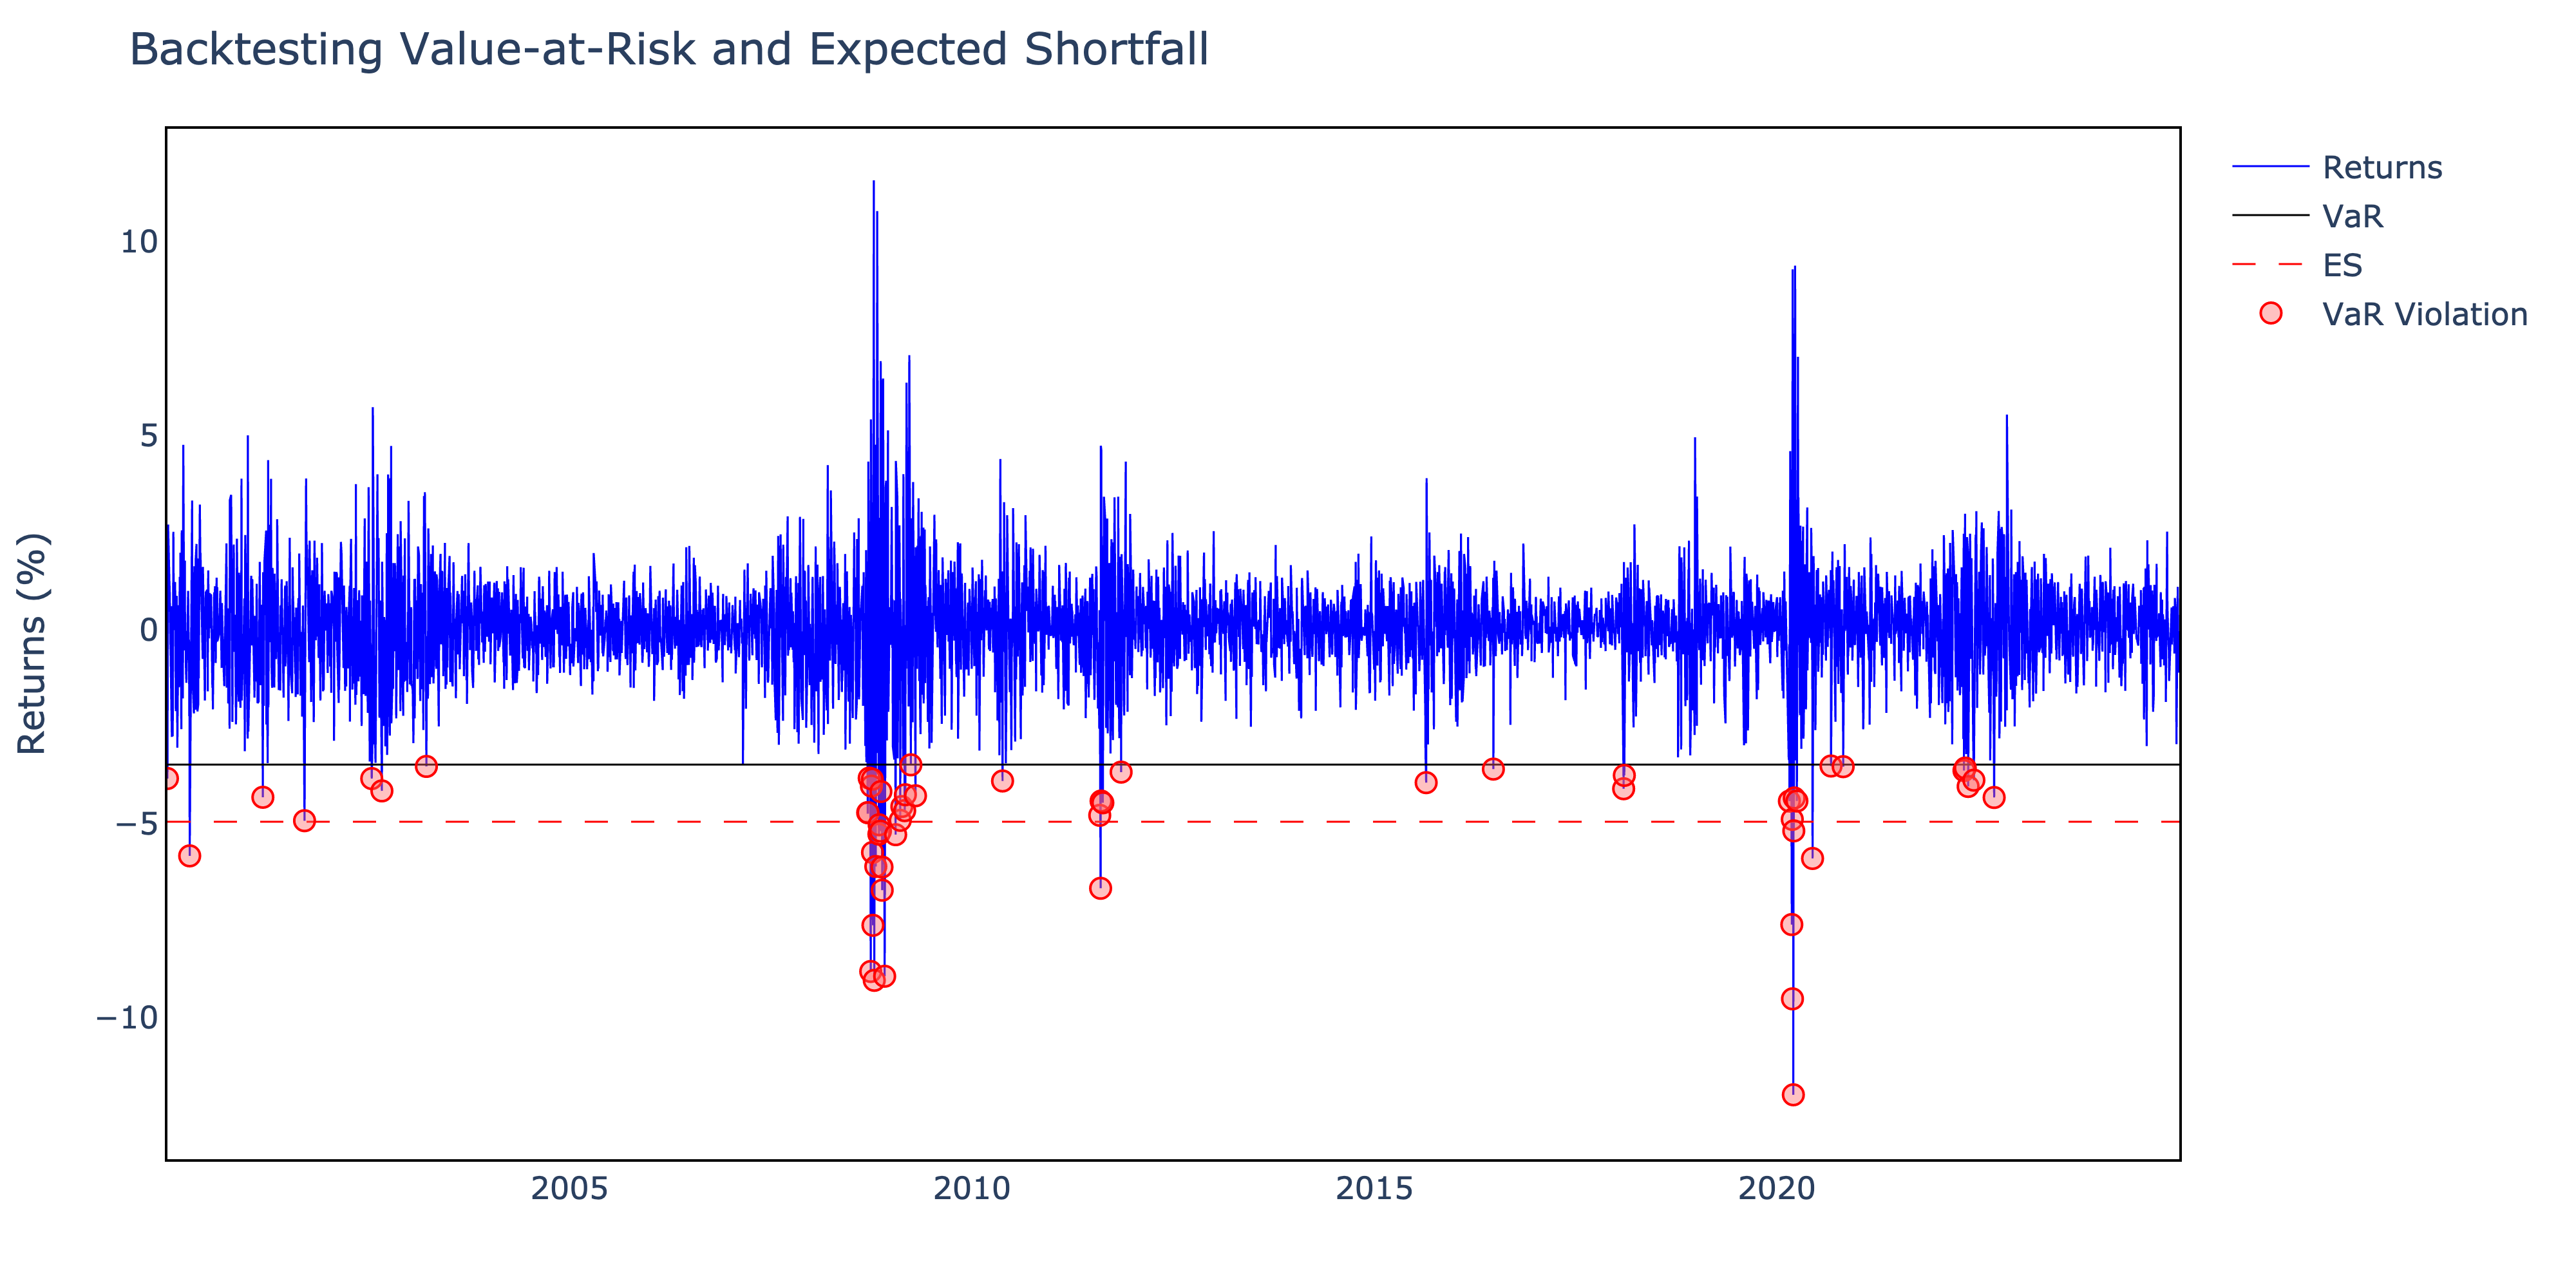

In [10]:
# Plot backtest
pv.plot_backtest(evt_results, interactive=False)

In [11]:
evt_results.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2000-01-04,-0.038345,0.034754,True,3475.408224,0.049478,4947.849694
2000-01-05,0.001922,0.034754,False,3475.408224,0.049478,4947.849694
2000-01-06,0.000956,0.034754,False,3475.408224,0.049478,4947.849694
2000-01-07,0.027090,0.034754,False,3475.408224,0.049478,4947.849694
2000-01-10,0.011190,0.034754,False,3475.408224,0.049478,4947.849694


#### Backtesting EVT

Notice how, despite the very high precision in matching the total number of violations, the EVT model is **not time-varying**, and thus fails the **Christoffersen independence test** — indicating that violations are not randomly distributed over time.

In [12]:
# Count violations
evt_violations, evt_violation_rate = pv.count_violations(evt_results)

# Kupiec Test (Unconditional Coverage)
evt_kupiec = pv.kupiec_test(
    total_violations=evt_violations,
    total_days=len(evt_results),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
evt_christoffersen = pv.christoffersen_test(evt_results)

# Joint Test (Conditional Coverage)
evt_joint = pv.joint_lr_test(
    LR_uc=evt_kupiec["LR_uc"],
    LR_c=evt_christoffersen["LR_c"]
)

In [13]:
# Summary output
print(f"\n--- EVT VaR Backtesting Summary ---")
print(f"Total Violations     : {evt_violations}")
print(f"Violation Rate       : {evt_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {evt_kupiec['LR_uc']:.4f}")
print(f"p-value             : {evt_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {evt_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {evt_christoffersen['LR_c']:.4f}")
print(f"p-value             : {evt_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {evt_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {evt_joint['LR_total']:.4f}")
print(f"p-value             : {evt_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {evt_joint['reject_null']}")


--- EVT VaR Backtesting Summary ---
Total Violations     : 57
Violation Rate       : 0.91%

Kupiec Test (UC):
LR_uc               : 0.5734
p-value             : 0.4489
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 9.9755
p-value             : 0.0016
Reject Null (5%)    : True

Joint Test (Conditional Coverage):
LR_total            : 10.5489
p-value             : 0.0051
Reject Null (5%)    : True


---

## Part 2: Combining EVT and Simulation Methods

In this section, we apply **WHS** and **FHS** simulation methods to a sample equity and options portfolio to generate the 1-day profit-and-loss distribution. We then use **Extreme Value Theory (EVT)** to extract **tail-based VaR and ES** estimates from the simulated losses, focusing on extreme quantiles beyond the 99% level.

Our package provides simple functions to automatically build your portfolio: prices are downloaded from Yahoo Finance, you specify the number of shares, and optionally convert everything to your base currency (USD in our case). Those are particularly useful to check common problems like missing values, stability of the VCV matrix etc.

Our example portfolio follows a stylized global equity strategy:  
- Long positions in broad market, regional, and sector ETFs (VT, SPY, VGK, EWJ, VWO)  
- Exposure to leading firms in tech, healthcare, and consumer sectors (AAPL, JNJ, PG, UNH, NVS)  
- A small short position in industrials (XLI) to hedge against cyclical downturns

We assume a **buy-and-hold** or "lazy portfolio" strategy. No active trading or rebalancing is considered. If the portfolio composition changes, all subsequent VaR and ES metrics must be recomputed from that point onward.

In [14]:
# Define shares — globally diversified portfolio
shares = pd.Series({
    "VT": 120,     # Global equity ETF
    "SPY": 80,     # US large-cap ETF
    "VGK": 60,     # Europe ETF
    "EWJ": 40,     # Japan ETF
    "VWO": 60,     # Emerging Markets ETF
    "AAPL": 50,    # Apple — tech
    "JNJ": 50,     # Johnson & Johnson — healthcare
    "PG": 40,      # Procter & Gamble — consumer staples
    "UNH": 40,     # UnitedHealth — healthcare
    "NVS": 30,     # Novartis — Swiss healthcare
    "XLI": -30     # US industrials sector ETF — short hedge
})

# Download prices and convert to base currency
tickers = shares.index.tolist()
raw_prices = pv.get_raw_prices(tickers, start="2023-01-01", end="2025-01-01")
prices_usd = pv.convert_to_base_currency(raw_prices, base_currency="USD")

# Compute monetary position values over time
portfolio_matrix = pv.create_portfolio(prices_usd, shares)

# Compute portfolio returns and statistics
portfolio_returns = pv.compute_returns(portfolio_matrix)

[currency detection] AAPL: USD
[currency detection] EWJ: USD
[currency detection] JNJ: USD
[currency detection] NVS: USD
[currency detection] PG: USD
[currency detection] SPY: USD
[currency detection] UNH: USD
[currency detection] VGK: USD
[currency detection] VT: USD
[currency detection] VWO: USD
[currency detection] XLI: USD


In [15]:
prices_usd.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,257.286682,65.916412,142.416550,94.822296,165.742447,597.729492,500.394104,62.738388,118.741814,44.595383,133.343323
2024-12-26,258.103729,66.680229,142.152908,94.870506,166.939377,597.769348,505.387146,62.905247,118.880699,44.485809,133.442703
2024-12-27,254.685867,67.186142,141.635391,94.860863,166.321289,591.476868,504.240234,62.699131,117.948227,44.326435,132.448776
2024-12-30,251.307877,66.620720,139.965637,93.838882,163.927460,584.727173,502.074921,62.286896,116.807434,43.937958,131.116943
2024-12-31,249.534180,66.561195,141.215515,93.819595,164.476868,582.599915,500.156769,62.296711,116.539597,43.868229,130.957916


In [16]:
# Compute latest portfolio value and weights
latest_prices = prices_usd.iloc[-1]
portfolio_value_usd = (shares * latest_prices).sum()
weights = (shares * latest_prices) / portfolio_value_usd

# Print final portfolio value and weights
print(f"\nFinal portfolio value in USD: {portfolio_value_usd:,.2f}\n")
print("Portfolio weights (based on latest prices):")
print(weights.round(4).sort_values(ascending=False))


Final portfolio value in USD: 114,633.77

Portfolio weights (based on latest prices):
SPY     0.4066
UNH     0.1745
VT      0.1220
AAPL    0.1088
JNJ     0.0616
PG      0.0574
VGK     0.0326
NVS     0.0246
EWJ     0.0232
VWO     0.0230
XLI    -0.0343
dtype: float64


A quick way to observe the correlations of our portfolio!


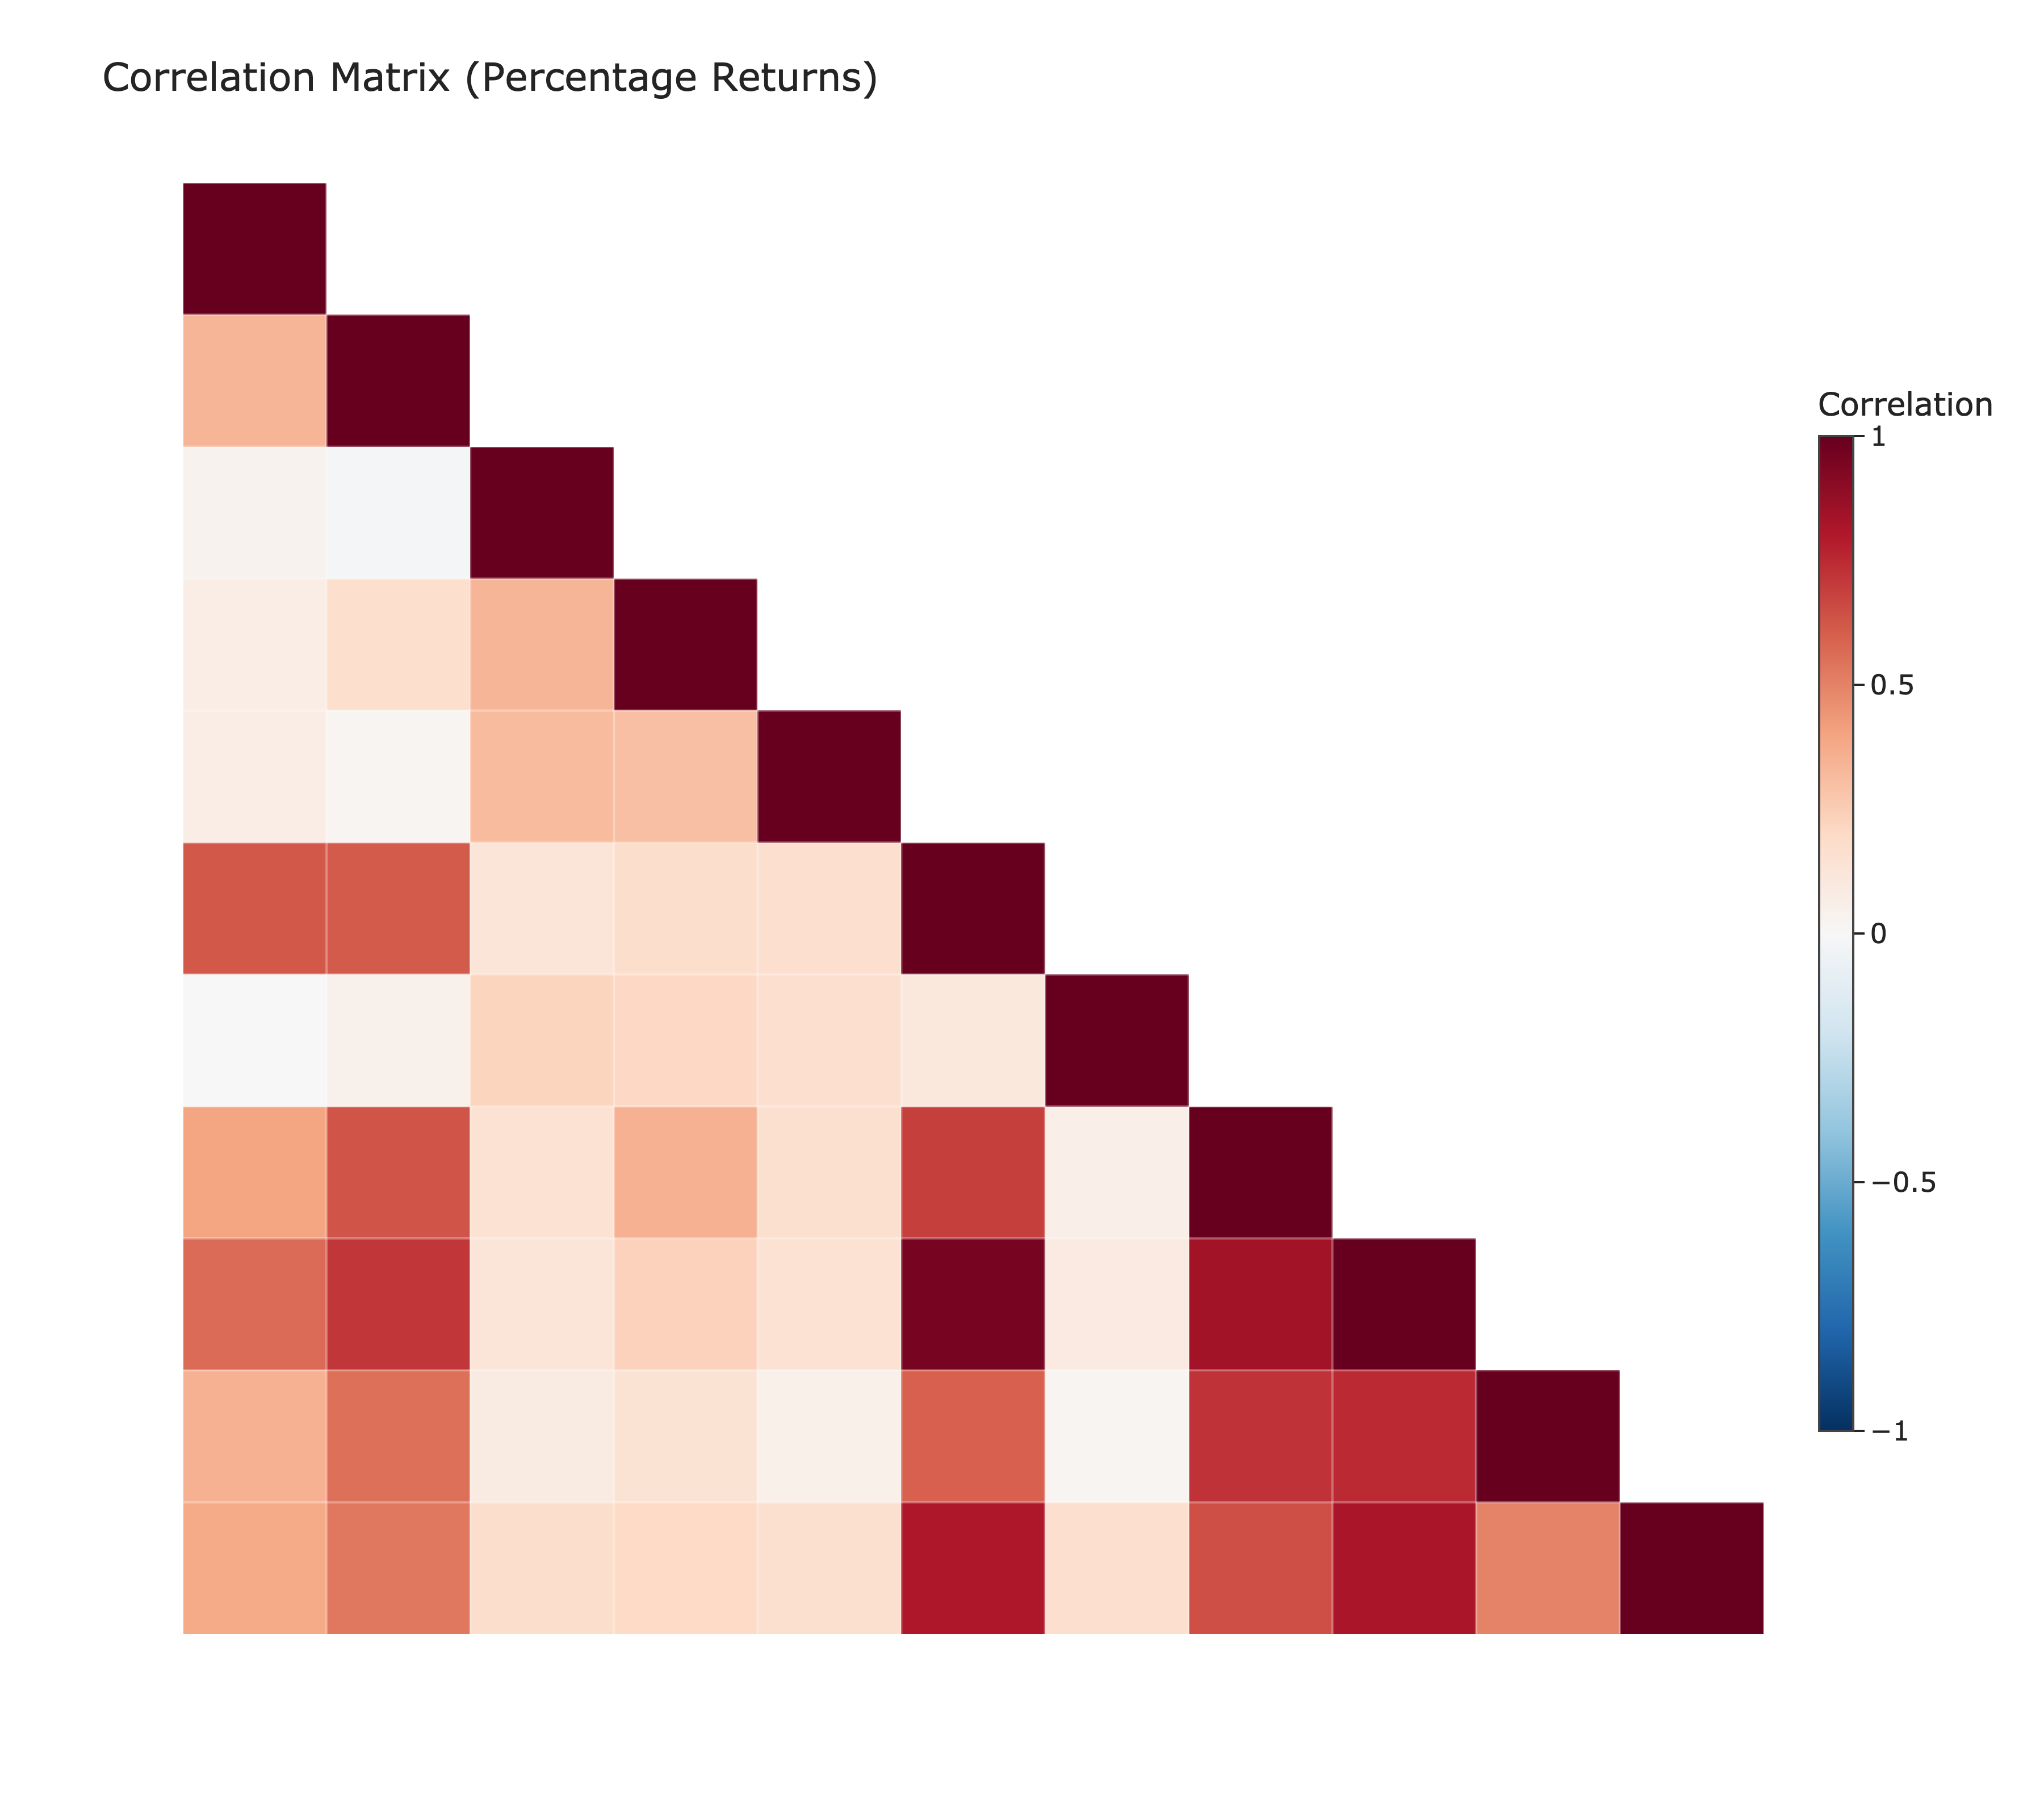

In [17]:
pv.plot_correlation_matrix(portfolio_matrix, interactive=False)

In [18]:
portfolio_matrix.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,12864.334106,2636.656494,7120.827484,2844.668884,6629.697876,47818.359375,20015.764160,3764.303284,14249.017639,2675.722961,-4000.299683
2024-12-26,12905.186462,2667.209167,7107.645416,2846.115189,6677.575073,47821.547852,20215.485840,3774.314804,14265.683899,2669.148560,-4003.281097
2024-12-27,12734.293365,2687.445679,7081.769562,2845.825882,6652.851562,47318.149414,20169.609375,3761.947861,14153.787231,2659.586105,-3973.463287
2024-12-30,12565.393829,2664.828796,6998.281860,2815.166473,6557.098389,46778.173828,20082.996826,3737.213745,14016.892090,2636.277466,-3933.508301
2024-12-31,12476.708984,2662.447815,7060.775757,2814.587860,6579.074707,46607.993164,20006.270752,3737.802658,13984.751587,2632.093735,-3928.737488


In [19]:
portfolio_returns.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,0.011478,-0.000602,0.003992,-0.001016,0.004937,0.011115,-0.000474,0.005506,0.007915,0.004037,0.007813
2024-12-26,0.003176,0.011588,-0.001851,0.000508,0.007222,0.000067,0.009978,0.002660,0.001170,-0.002457,0.000745
2024-12-27,-0.013242,0.007587,-0.003641,-0.000102,-0.003702,-0.010527,-0.002269,-0.003277,-0.007844,-0.003583,-0.007448
2024-12-30,-0.013263,-0.008416,-0.011789,-0.010773,-0.014393,-0.011412,-0.004294,-0.006575,-0.009672,-0.008764,-0.010055
2024-12-31,-0.007058,-0.000893,0.008930,-0.000206,0.003352,-0.003638,-0.003820,0.000158,-0.002293,-0.001587,-0.001213


If you want to **save the DataFrame shown above**, use:

```python
portfolio_returns.to_csv("portfolio_returns.csv")
```

If you want to **import your own CSV**, make sure the first column contains dates and use:

```python
df = pd.read_csv("your_file.csv", index_col=0, parse_dates=True)
```

This ensures:
- The first column becomes the date index
- Dates are properly parsed for the analysis

Note: You are responsible for data cleaning and pre-processing when using your own files. Our data-download functions will print warnings if there are issues, but they do not perform automatic cleaning.

In [20]:
# Use existing spot prices and volatilities
S0 = prices_usd.iloc[-1]
volatility_annualized = portfolio_returns.std() * np.sqrt(252)

# Select representative tickers for options
selected_tickers = ["VT", "SPY", "AAPL", "JNJ", "XLI"]

# Create example option contracts
options = [
    {
        "asset_index": tickers.index("AAPL"),
        "K": 200,
        "T": 60 / 252,
        "r": 0.01,
        "sigma": volatility_annualized["AAPL"],
        "type": "call",
        "quantity": 3000,         # number of contracts
        "contract_size": 100         # unit size per contract
    },
    {
        "asset_index": tickers.index("XLI"),
        "K": 115,
        "T": 45 / 252,
        "r": 0.01,
        "sigma": volatility_annualized["XLI"],
        "type": "put",
        "quantity": 5000,
        "contract_size": 100
    },
    {
        "asset_index": tickers.index("VT"),
        "K": 100,
        "T": 90 / 252,
        "r": 0.01,
        "sigma": volatility_annualized["VT"],
        "type": "call",
        "quantity": 2500,
        "contract_size": 100
    }
]

In [21]:
# Print values of equity positions (already defined)
print("\nEquity Positions (latest prices):")
total_equity_value = 0
for tkr in tickers:
    position_value = shares[tkr] * S0[tkr]
    print(f"{tkr:5}: {shares[tkr]:4} × {S0[tkr]:.2f} = {position_value:,.2f} USD")
    total_equity_value += position_value

# Price and print values of options
print("\nOption Values (Black-Scholes at time 0):")
total_option_value = 0
for i, opt in enumerate(options):
    spot = S0[tickers[opt["asset_index"]]]
    price_bs = pv.black_scholes_pricing(
        spot, opt["K"], opt["T"], opt["r"], opt["sigma"], opt["type"]
    )
    option_value = price_bs * opt["quantity"] * opt["contract_size"]
    print(f"Option {i+1} on {tickers[opt['asset_index']]} ({opt['type']}): "
          f"BS = {price_bs:.2f} × {opt['quantity']} × {opt['contract_size']} = {option_value:,.2f} USD")
    total_option_value += option_value

# Print new portfolio value
total_portfolio_value = total_equity_value + total_option_value
print(f"\nTotal equity value:     {total_equity_value:,.2f} USD")
print(f"Total option value:     {total_option_value:,.2f} USD")
print(f"Total portfolio value:  {total_portfolio_value:,.2f} USD")


Equity Positions (latest prices):
VT   :  120 × 116.54 = 13,984.75 USD
SPY  :   80 × 582.60 = 46,607.99 USD
VGK  :   60 × 62.30 = 3,737.80 USD
EWJ  :   40 × 66.56 = 2,662.45 USD
VWO  :   60 × 43.87 = 2,632.09 USD
AAPL :   50 × 249.53 = 12,476.71 USD
JNJ  :   50 × 141.22 = 7,060.78 USD
PG   :   40 × 164.48 = 6,579.07 USD
UNH  :   40 × 500.16 = 20,006.27 USD
NVS  :   30 × 93.82 = 2,814.59 USD
XLI  :  -30 × 130.96 = -3,928.74 USD

Option Values (Black-Scholes at time 0):
Option 1 on AAPL (call): BS = 50.14 × 3000 × 100 = 15,042,544.64 USD
Option 2 on XLI (put): BS = 0.04 × 5000 × 100 = 18,396.70 USD
Option 3 on VT (call): BS = 16.94 × 2500 × 100 = 4,235,811.93 USD

Total equity value:     114,633.77 USD
Total option value:     19,296,753.26 USD
Total portfolio value:  19,411,387.03 USD


### Historical Bootstrap Simulation (HBS)

Here we apply the **Historical Bootstrap Simulation (HBS)** method exactly as implemented in the `simulations.ipynb` notebook. This method resamples past return vectors with replacement to generate new simulated profit-and-loss outcomes, preserving the empirical distribution without assuming any parametric structure.

For a deeper discussion of the HBS methodology and its interpretation, refer to the **simulations notebook**.


In [22]:
# General simulations parameters
simulations = 10_000
seed = 1

In [23]:
# Bootstrapped Historical Simulation 
var_historical_bootstrap, pnl_historical_bootstrap = pv.historical_simulation_var(
    price_data=prices_usd,
    shares=shares.values,
    options=options,
    confidence_level=confidence_level,
    bootstrap=True,
    simulations=simulations,
    seed=seed
)

# ES
es_historical_bootstrap = pv.simulation_es(var_historical_bootstrap, pnl_historical_bootstrap)

# Print results
print(f"Bootstrapped Historical VaR (99%):   {var_historical_bootstrap:,.2f} USD")
print(f"Bootstrapped Historical ES  (99%):   {es_historical_bootstrap:,.2f} USD")

Bootstrapped Historical VaR (99%):   4,556,188.05 USD
Bootstrapped Historical ES  (99%):   5,831,483.05 USD


### Filtered Historical Simulation (FHS)

Here we apply the **Filtered Historical Simulation (FHS)** exactly as in the `simulations.ipynb` notebook. Again, for a deeper discussion of FHS and its assumptions, refer to the **simulations notebook**.

In [24]:
# Run Filtered Historical Simulation (1-day horizon, 99% confidence)
var_fhs, pnl_fhs = pv.filtered_historical_simulation_var(
    price_data=prices_usd,
    shares=shares.values,
    options=options,
    confidence_level=confidence_level,
    bootstrap=True,
    simulations=simulations,
    seed=seed,
    p=1,
    q=1,
    model="GJR",         # or "EGARCH", "GJR", "APARCH"
    distribution="skewt"  # or "t", "ged", "skewt"
)

# Calculate ES
es_fhs = pv.simulation_es(var_fhs, pnl_fhs)

# Display results
print(f"Filtered Historical Simulation VaR (99%):   {var_fhs:,.2f} USD")
print(f"Filtered Historical Simulation ES  (99%):   {es_fhs:,.2f} USD")

Filtered Historical Simulation VaR (99%):   7,158,719.27 USD
Filtered Historical Simulation ES  (99%):   8,041,869.70 USD


### Applying EVT on Simulated Profit and Loss

In [75]:
# New EVT parameters
new_confidence_level=0.9997
new_threshold_percentile=95

In [76]:
# Apply EVT on Historical Bootstrap
var_evt_hbs = pv.evt_var_simulations(
    profit_and_loss=pnl_historical_bootstrap,
    confidence_level=new_confidence_level,
    threshold_percentile=new_threshold_percentile
)

es_evt_hbs = pv.evt_es_simulations(
    profit_and_loss=pnl_historical_bootstrap,
    var_evt_simulations=var_evt_hbs,
    threshold_percentile=new_threshold_percentile
)

# Print results
print(f"EVT HBS VaR (99.97%):   {var_evt_hbs:,.2f} USD")
print(f"EVT HBS ES  (99.97%):   {es_evt_hbs:,.2f} USD")


EVT HBS VaR (99.97%):   6,471,994.57 USD
EVT HBS ES  (99.97%):   6,557,154.79 USD


In [77]:
# Apply EVT on FHS
var_evt_fhs = pv.evt_var_simulations(
    profit_and_loss=pnl_fhs,
    confidence_level=new_confidence_level,
    threshold_percentile=new_threshold_percentile
)

es_fhs_evt = pv.evt_es_simulations(
    profit_and_loss=pnl_fhs,
    var_evt_simulations=var_evt_fhs,
    threshold_percentile=new_threshold_percentile
)

# Print results
print(f"EVT FHS VaR (99.97%):   {var_evt_fhs:,.2f} USD")
print(f"EVT FHS ES  (99.97%):   {es_fhs_evt:,.2f} USD")

EVT FHS VaR (99.97%):   6,707,089.67 USD
EVT FHS ES  (99.97%):   6,724,904.78 USD


#### Results Comparison

With the updated EVT fits, both HBS and FHS have **similar exceedance counts** (232 vs 239), but differ sharply in their **tail characteristics**. The **FHS model** has a **heavier tail** ($\xi = 1.05$ vs $0.66$), indicating greater theoretical tail risk. However, the **EVT-adjusted VaR and ES are higher for HBS** (e.g., VaR: 7.41M USD vs 6.44M USD).

This counterintuitive result is driven by the **lower threshold** used in HBS (~3.93M USD vs ~5.00M USD), which causes the tail fit to start earlier and incorporate more moderate large losses. As a result, EVT inflates the tail estimates more aggressively despite the lower shape. This highlights how **threshold placement** can outweigh tail heaviness when estimating risk at extreme quantiles.

#### Results Comparison

With the updated EVT fits, HBS and FHS have **similar exceedance counts** (485 vs 498) but different tail shapes. HBS shows a **heavier tail** ($\xi = 0.47$), while FHS is nearly exponential ($\xi \approx 0.01$).  

At the extreme $99.97\%$ level, both methods give consistent estimates (HBS: VaR $6.47$M, ES $6.56$M; FHS: VaR $6.71$M, ES $6.72$M). The closeness of VaR and ES reflects relatively thin fitted tails, especially for FHS.  

The fact that EVT sometimes produces a **lower 99.97% VaR than the 99% historical or FHS values** is not an error but a **threshold effect**: EVT only fits losses above $u$, so extrapolation may ignore moderate extremes included in historical simulation. This highlights the sensitivity of EVT results to threshold placement.

In [78]:
# EVT parameters for HBS
evt_params_hbs = pv.fit_evt_parameters(pnl_historical_bootstrap, threshold_percentile=new_threshold_percentile)

print("\n--- EVT Parameters: HBS ---")
print(f"Shape (xi):              {evt_params_hbs['xi']:.4f}")
print(f"Scale (beta):            {evt_params_hbs['beta']:.4f}")
print(f"Threshold (u):           {evt_params_hbs['threshold_u']:,.2f} USD")
print(f"Exceedances:             {evt_params_hbs['num_exceedances']} out of {evt_params_hbs['total_observations']}")

# EVT parameters for FHS
evt_params_fhs = pv.fit_evt_parameters(pnl_fhs, threshold_percentile=new_threshold_percentile)

print("\n--- EVT Parameters: FHS ---")
print(f"Shape (xi):              {evt_params_fhs['xi']:.4f}")
print(f"Scale (beta):            {evt_params_fhs['beta']:.4f}")
print(f"Threshold (u):           {evt_params_fhs['threshold_u']:,.2f} USD")
print(f"Exceedances:             {evt_params_fhs['num_exceedances']} out of {evt_params_fhs['total_observations']}")



--- EVT Parameters: HBS ---
Shape (xi):              0.4730
Scale (beta):            475986.0491
Threshold (u):           3,390,154.84 USD
Exceedances:             485 out of 10000

--- EVT Parameters: FHS ---
Shape (xi):              0.0115
Scale (beta):            1367758.9238
Threshold (u):           4,605,770.10 USD
Exceedances:             498 out of 10000


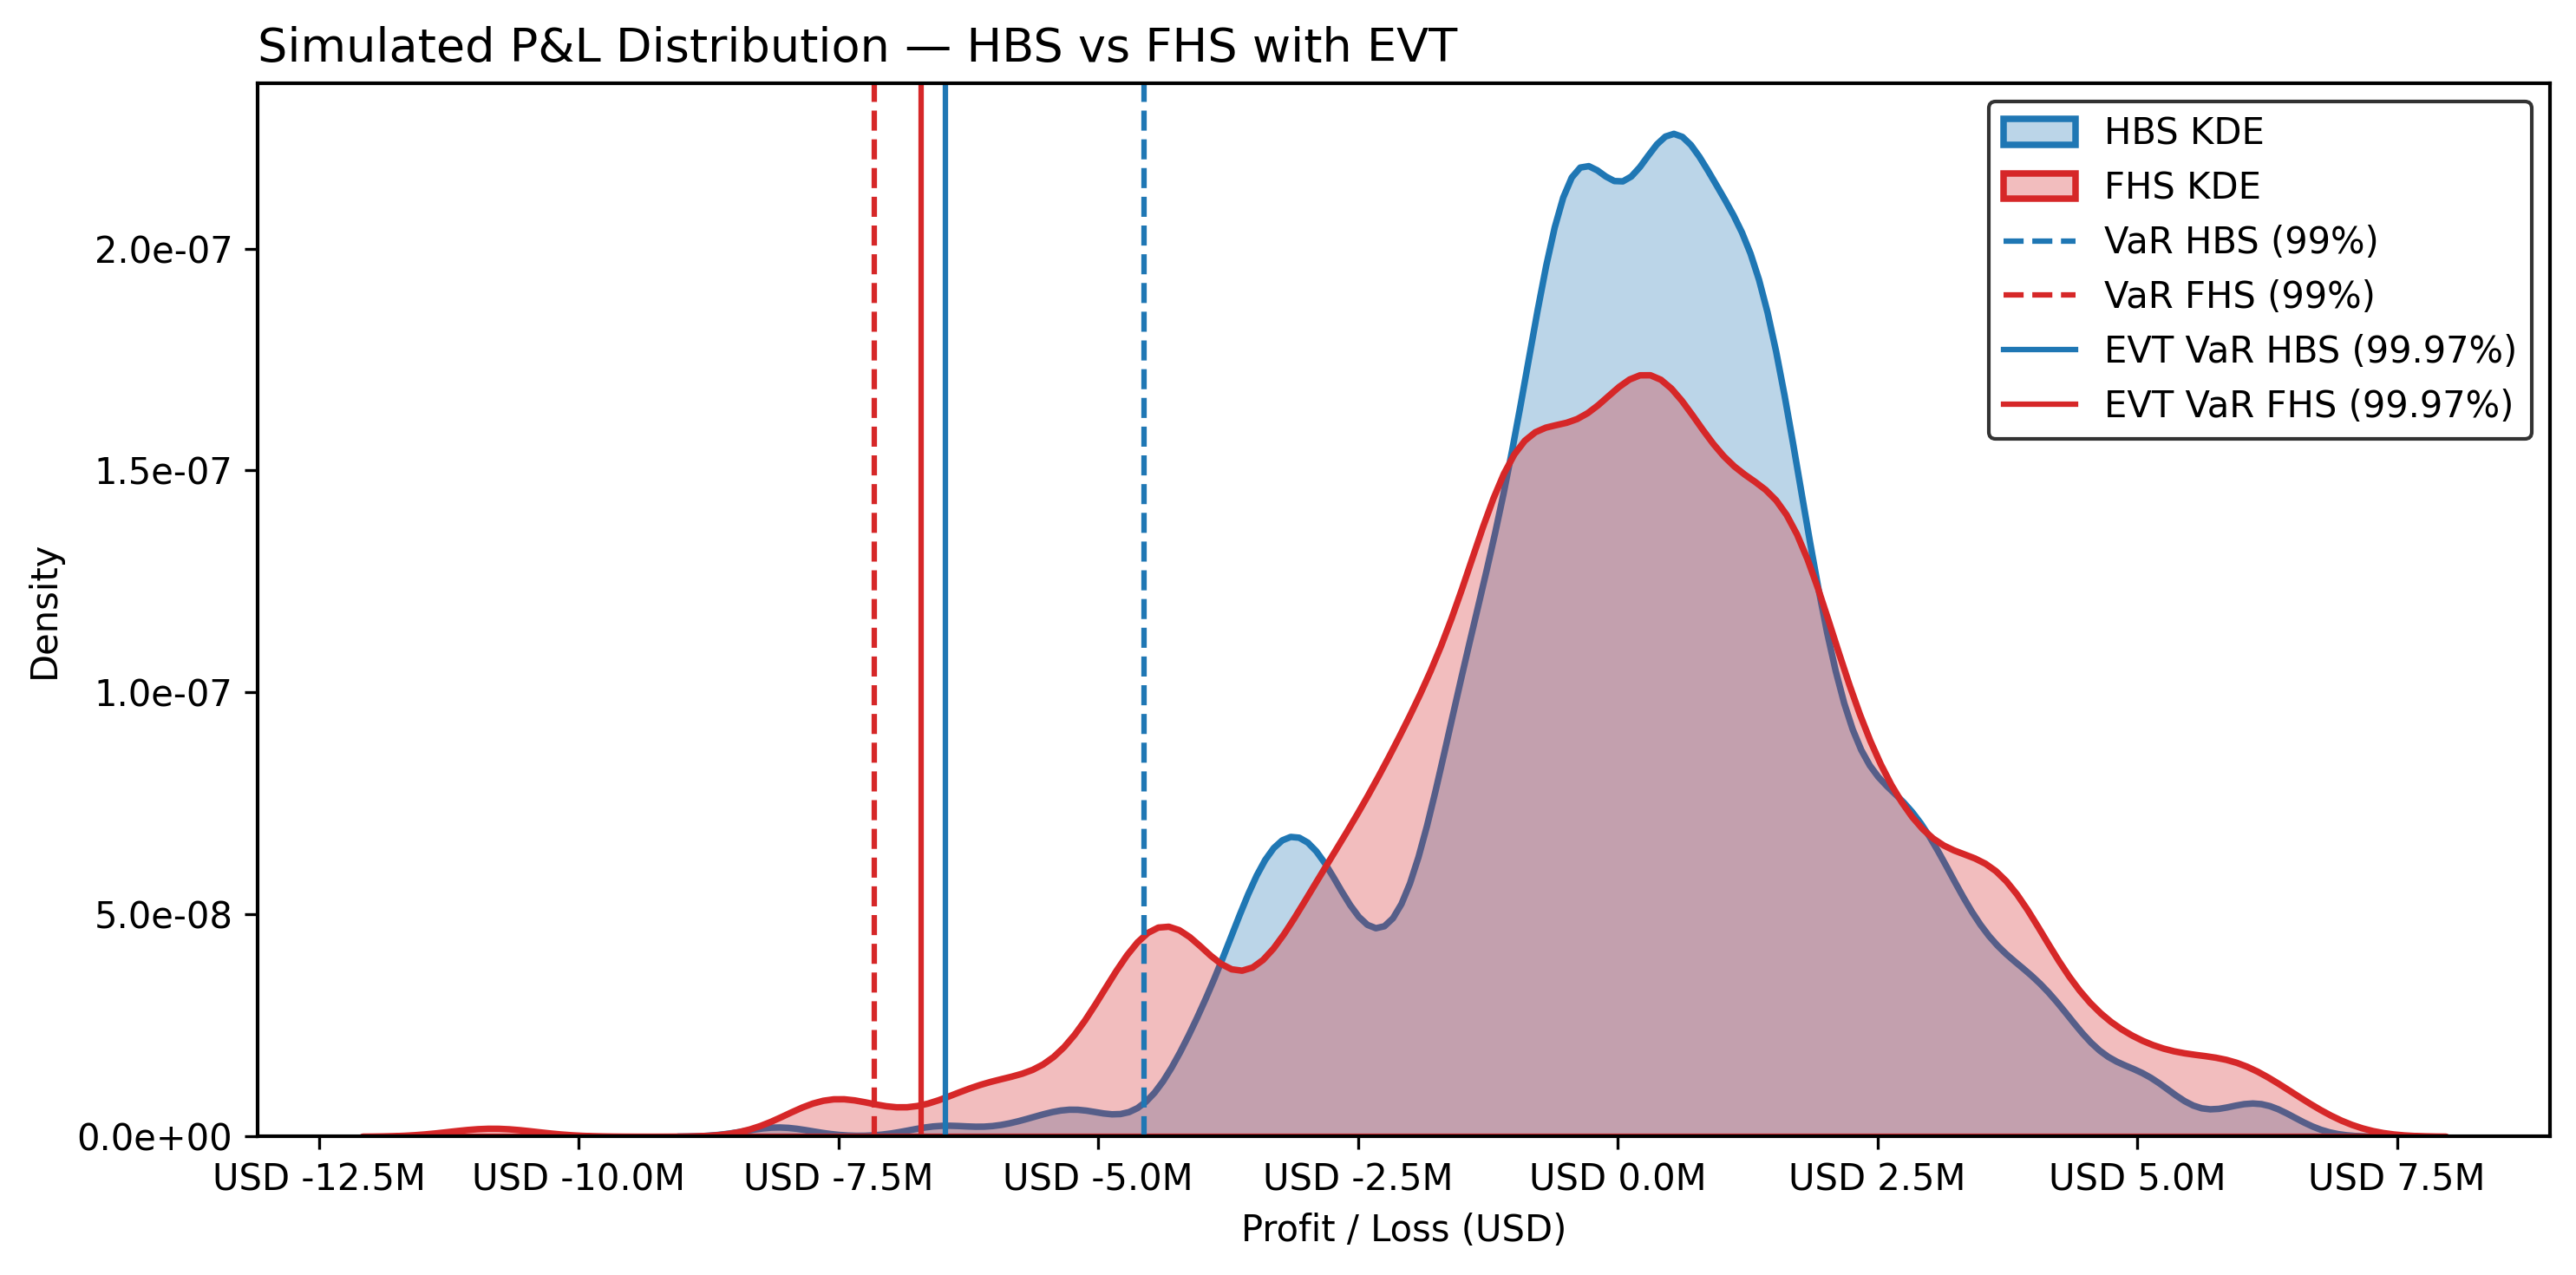

In [79]:
plt.figure(figsize=(10, 5), dpi=300)

# KDE plots
sns.kdeplot(pnl_historical_bootstrap, label="HBS KDE", fill=True, color="#1f77b4", linewidth=1.8, alpha=0.3)
sns.kdeplot(pnl_fhs, label="FHS KDE", fill=True, color="#d62728", linewidth=1.8, alpha=0.3)

# VaR lines: Standard
plt.axvline(-var_historical_bootstrap, color="#1f77b4", linestyle="--", linewidth=1.5, label="VaR HBS (99%)")
plt.axvline(-var_fhs, color="#d62728", linestyle="--", linewidth=1.5, label="VaR FHS (99%)")

# VaR lines: EVT
plt.axvline(-var_evt_hbs, color="#1f77b4", linestyle="-", linewidth=1.5, label="EVT VaR HBS (99.97%)")
plt.axvline(-var_evt_fhs, color="#d62728", linestyle="-", linewidth=1.5, label="EVT VaR FHS (99.97%)")

# Title and labels
plt.title("Simulated P&L Distribution — HBS vs FHS with EVT", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Profit / Loss (USD)")
plt.ylabel("Density")

# Axis styling
ax = plt.gca()
for side in ["top", "bottom", "left", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1)

ax.tick_params(width=0.8, color='black')

# Format axes
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"USD {x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1e}"))

# Legend
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()